phase 3.1

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('../data/processed/cleaned_medical_notes.csv') #to load the cleaned medical notes dataset from a CSV file into a pandas DataFrame for further analysis and modeling
print(df.shape)
print(df.columns.tolist())

(4951, 9)
['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'char_lenght', 'word_count', 'sentence_count', 'clean_text']


In [103]:
print(df['medical_specialty'].to_list())

['Allergy / Immunology', 'Bariatrics', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Neurology', 'Bariatrics', 'Dentistry', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Urology', 'General Medicine', 'Urology', 'Bariatrics', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Uro

In [104]:
not_specialties = [
    'SOAP / Chart / Progress Notes', 'Office Notes', 'Letters',
    'Discharge Summary', 'Emergency Room Reports',
    'Consult - History and Phy.', 'IME-QME-Work Comp etc.'
]
df = df[~df['medical_specialty'].isin(not_specialties)]
print("rows:", len(df), "| classes:", df['medical_specialty'].nunique())

rows: 4001 | classes: 33


In [105]:
X = df['clean_text']          # features (text, to be vectorized)
y = df['medical_specialty']   # labels (what we predict)

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% held out for testing
    stratify=y,          # preserve class proportions in both sets
    random_state=42      # reproducible split
)
print("train:", len(X_train), "| test:", len(X_test))

train: 3200 | test: 801


In [107]:
custom_noise = ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear', 'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold'] #to create a list of noise words to remove from the text data during vectorization, these words are identified as de identified words and common words that are not informative for specialty classification


tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    stop_words=custom_noise
)

X_train_tfidf = tfidf.fit_transform(X_train)   # FIT (learn vocab + IDF) + transform
X_test_tfidf  = tfidf.transform(X_test)        # transform ONLY (reuse train's vocab)

print("train matrix:", X_train_tfidf.shape)
print("test matrix:", X_test_tfidf.shape)

train matrix: (3200, 10000)
test matrix: (801, 10000)


3.2 Model 1 Logistic Regression (the interpretable baseline)

In [108]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
logreg_preds = logreg.predict(X_test_tfidf)

3.2 Model 2 Multinomial Naive Bayes (The Text Specialist)

In [109]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

Model 3 — Random Forest (the non-linear option)

In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_tfidf, y_train)
rf_preds = rf.predict(X_test_tfidf)

Phase 3.3
Metric 1 — Macro F1 (the honest metric)

In [111]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

for name, preds in [('Logistic Regression', logreg_preds),
                    ('Naive Bayes', nb_preds),
                    ('Random Forest', rf_preds)]:
    print(f"\n===== {name} =====")
    print("Accuracy:    ", round(accuracy_score(y_test, preds), 3))
    print("Macro F1:    ", round(f1_score(y_test, preds, average='macro'), 3))
    print("Weighted F1: ", round(f1_score(y_test, preds, average='weighted'), 3))


===== Logistic Regression =====
Accuracy:     0.448
Macro F1:     0.515
Weighted F1:  0.395

===== Naive Bayes =====
Accuracy:     0.401
Macro F1:     0.081
Weighted F1:  0.305

===== Random Forest =====
Accuracy:     0.335
Macro F1:     0.422
Weighted F1:  0.297


Metric 2 — Confusion Matrix (where the leaks are)

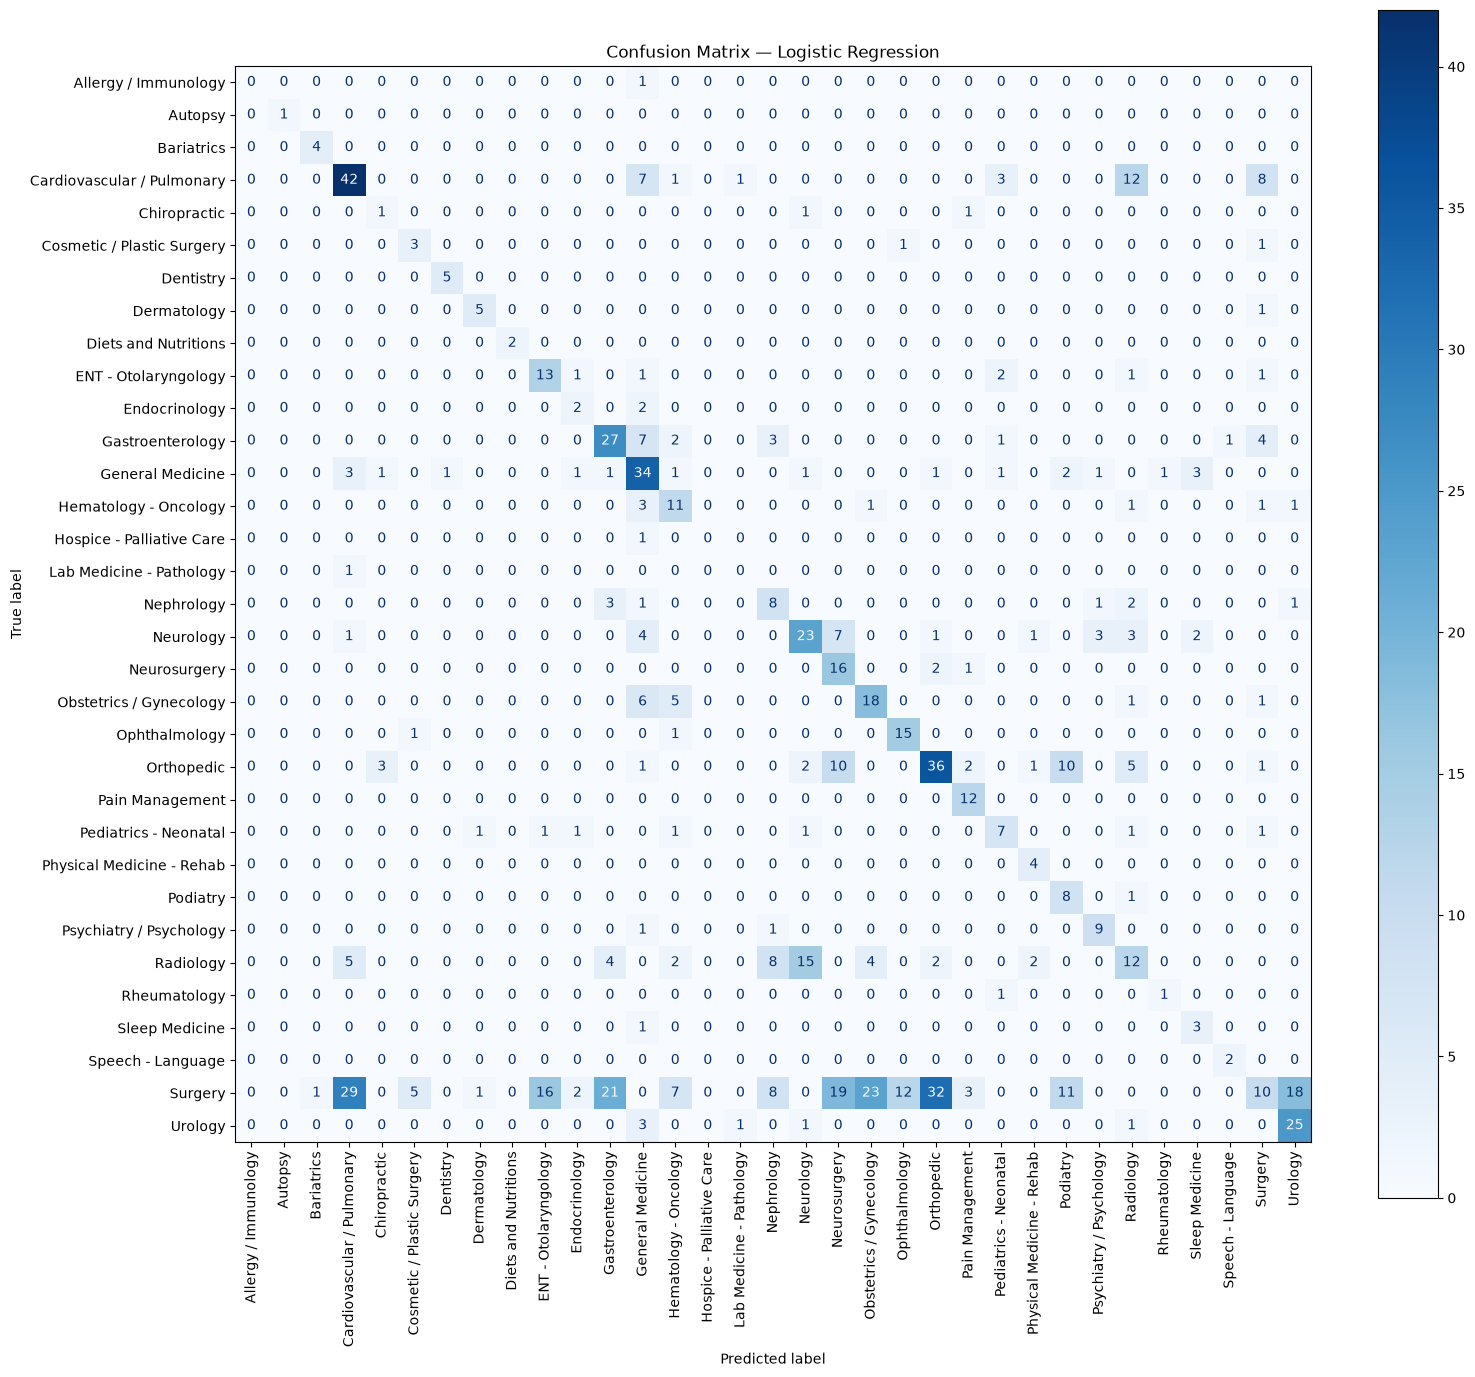

In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, logreg_preds, labels=labels)

fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

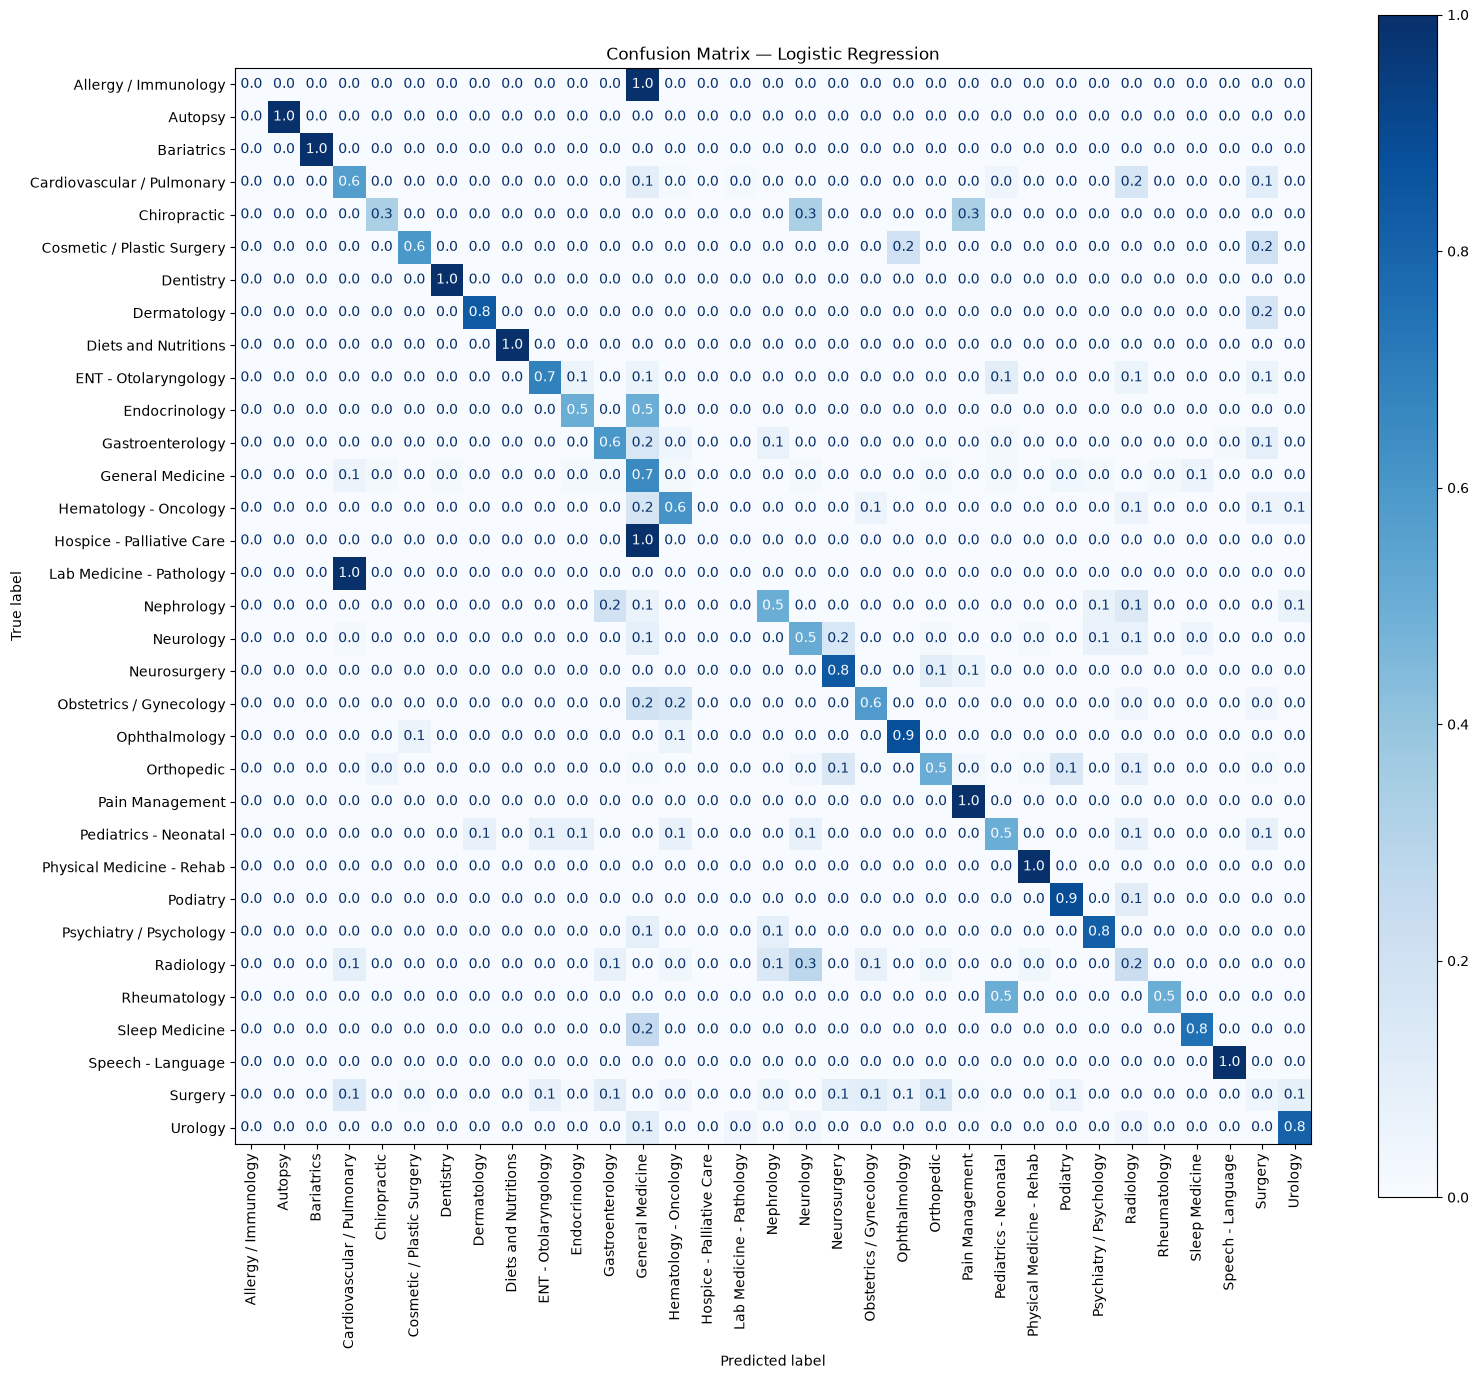

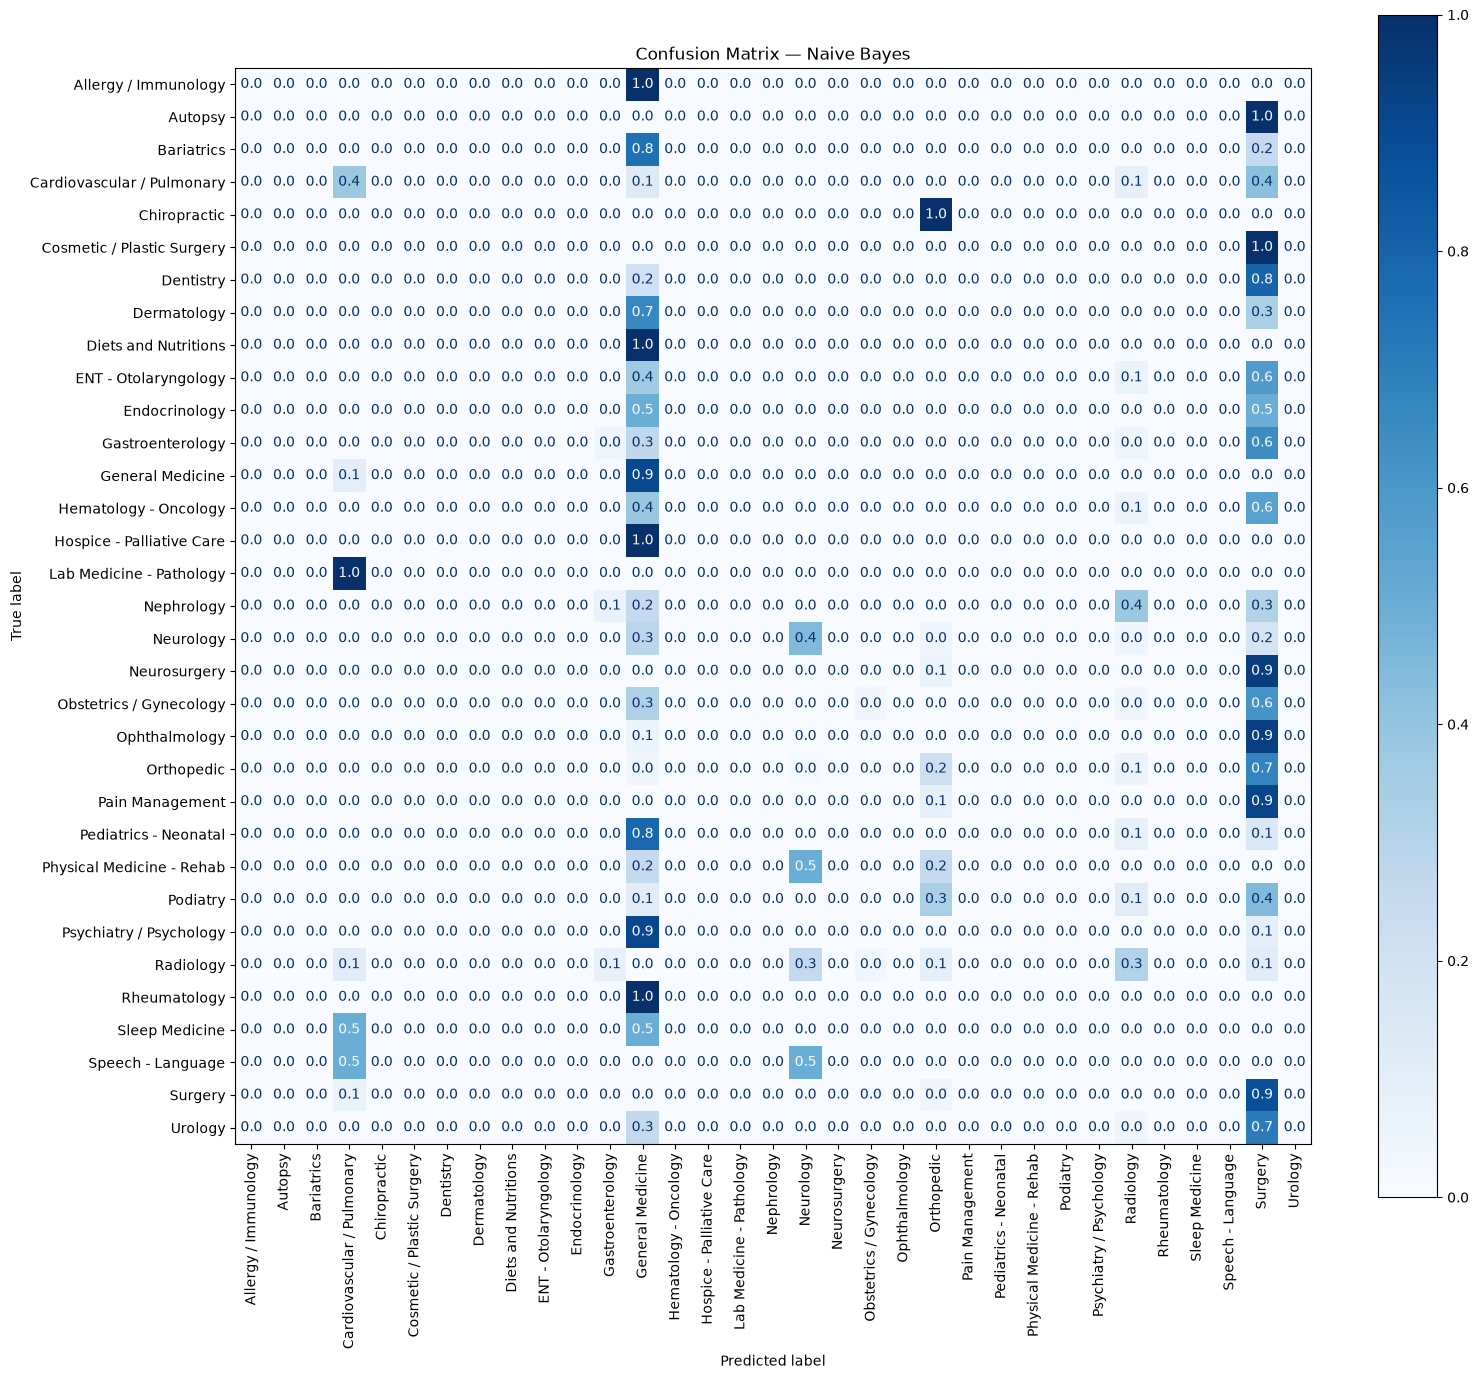

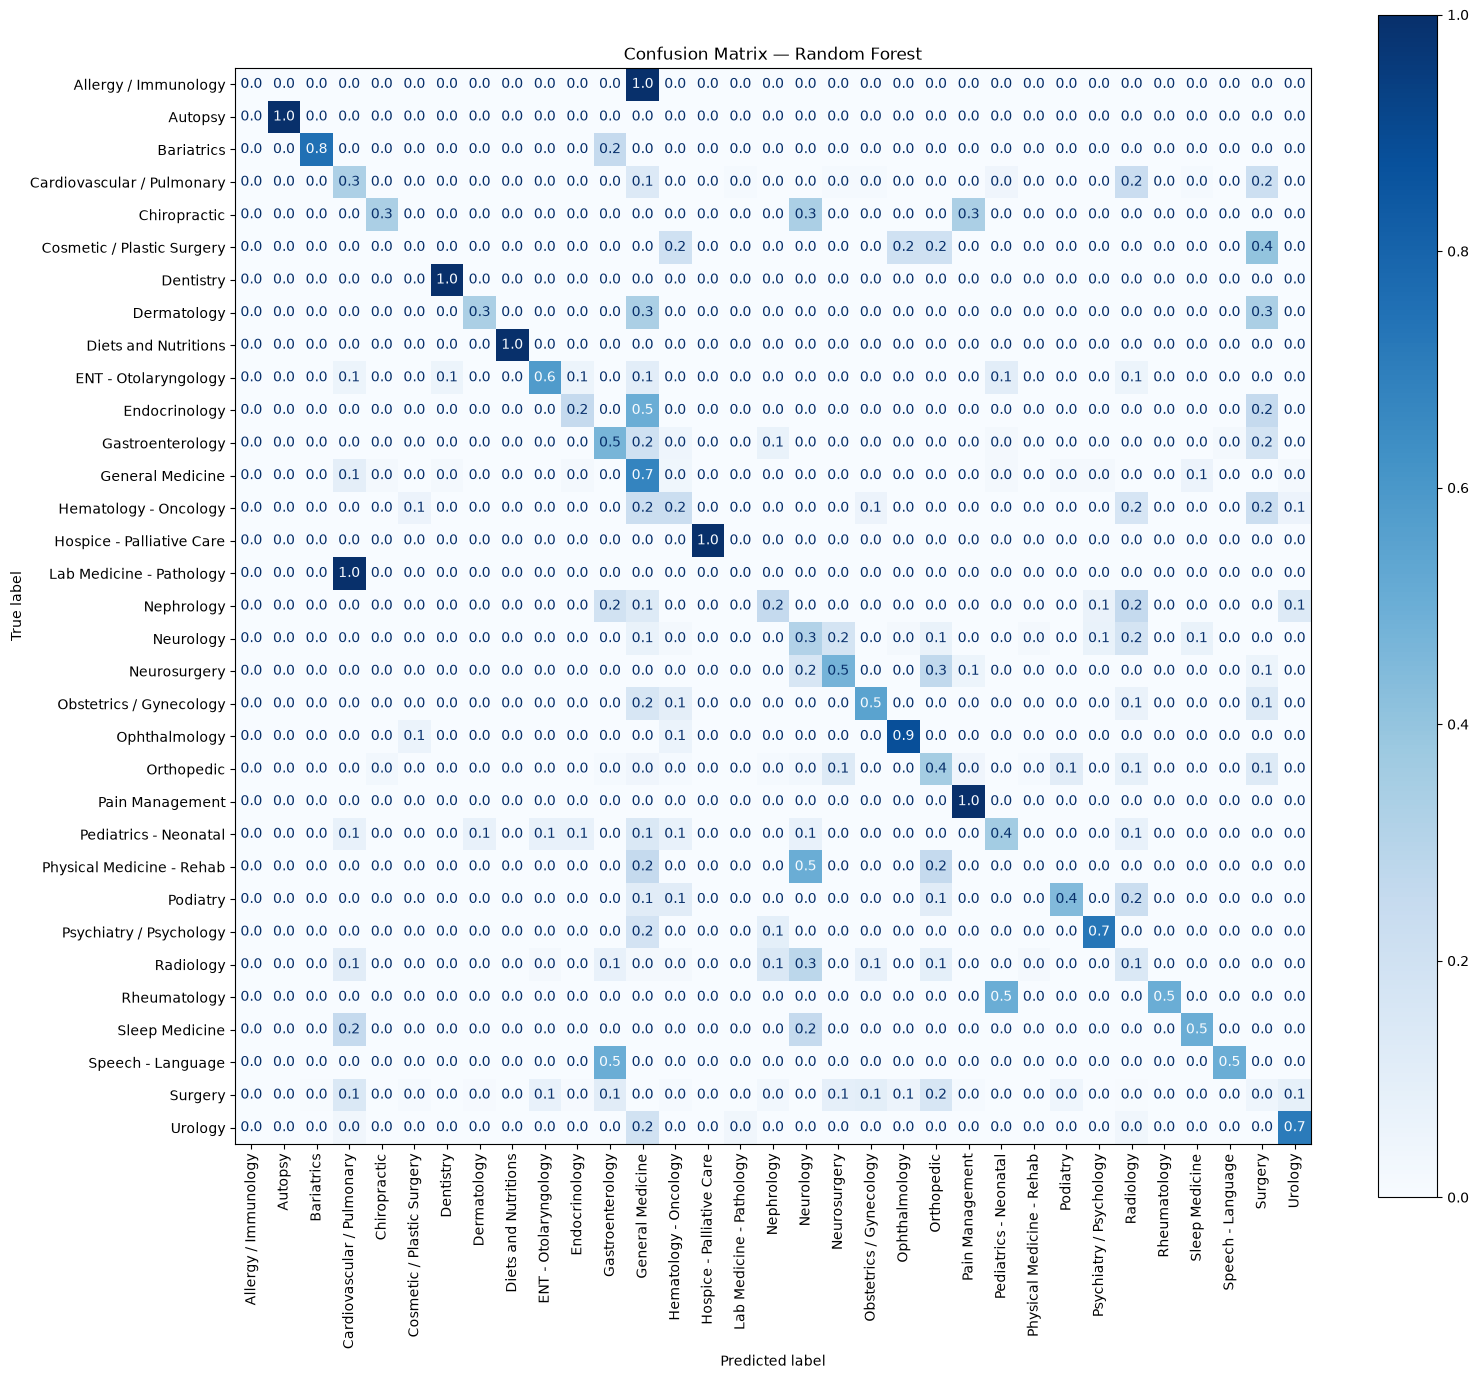

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())

models = [
    ('Logistic Regression', logreg_preds),
    ('Naive Bayes', nb_preds),
    ('Random Forest', rf_preds)
]

for name, preds in models:
    cm = confusion_matrix(y_test, preds, labels=labels, normalize='true')
    fig, ax = plt.subplots(figsize=(16, 14))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, xticks_rotation=90, cmap='Blues', values_format='.1f'
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

Metric 3: Error Analysis

In [114]:
import pandas as pd

# 1. get the model's probability for every class, per test note
probs = logreg.predict_proba(X_test_tfidf)

# 2. the model's confidence = the probability it gave its top choice
confidence = probs.max(axis=1)
predicted = logreg.classes_[probs.argmax(axis=1)]

# 3. assemble everything into one frame for inspection
results = pd.DataFrame({
    'true': y_test.values,
    'pred': predicted,
    'confidence': confidence,
    'text': X_test.values
})

# 4. keep only the WRONG ones, sorted by confidence (most confident first)
wrong = results[results['true'] != results['pred']].sort_values('confidence', ascending=False)

# 5. read the top 5 confident-but-wrong cases
for i, (_, row) in enumerate(wrong.head(5).iterrows(), 1):
    print(f"\n{'='*70}")
    print(f"CASE {i}  |  confidence: {row['confidence']:.2f}")
    print(f"TRUE: {row['true']}   →   PREDICTED: {row['pred']}")
    print(f"{'-'*70}")
    print(row['text'][:600])


CASE 1  |  confidence: 0.86
TRUE: Cardiovascular / Pulmonary   →   PREDICTED: Lab Medicine - Pathology
----------------------------------------------------------------------
gross description received fresh labeled patient name designated right upper lobe wedge x x cm wedge lung cm staple line x x cm sessile tumor surrounding pleural puckering b received fresh labeled patient name designated lymph node cm possible lymph node anthracotic pigment c received fresh labeled patient name designated right upper lobe x x cm lobe lung lung inflated formalin cm staple line lateral surface inked blue x x cm subpleural firm ill defined mass cm bronchial margin cm previously described staple line overlying pleura puckered received fresh labeled patient name designated lymph no

CASE 2  |  confidence: 0.83
TRUE: Urology   →   PREDICTED: Lab Medicine - Pathology
----------------------------------------------------------------------
specimens pelvis right pelvic obturator node pelvis left pelvic obtu

In [115]:
import numpy as np

feature_names = tfidf.get_feature_names_out()   # the words, in column order
classes = logreg.classes_                        # the specialties, in coefficient-row order

def top_words_for(specialty, n=10):
    # find which row of the coefficient matrix is this specialty
    idx = list(classes).index(specialty)
    coefs = logreg.coef_[idx]                     # coefficients for this specialty
    top_idx = np.argsort(coefs)[-n:][::-1]        # indices of the n largest
    return [(feature_names[i], round(coefs[i], 2)) for i in top_idx]

for spec in ['Cardiovascular / Pulmonary', 'Orthopedic', 'Neurology', 'Gastroenterology']:
    print(f"\n=== {spec} ===")
    print(top_words_for(spec))


=== Cardiovascular / Pulmonary ===
[('coronary', np.float64(1.85)), ('artery', np.float64(1.81)), ('chest', np.float64(1.65)), ('heart', np.float64(1.19)), ('coronary artery', np.float64(1.12)), ('atrial', np.float64(1.09)), ('pulmonary', np.float64(1.08)), ('lobe', np.float64(1.0)), ('aortic', np.float64(0.92)), ('catheter', np.float64(0.86))]

=== Orthopedic ===
[('fracture', np.float64(1.8)), ('knee', np.float64(1.64)), ('carpal', np.float64(1.2)), ('pain', np.float64(1.16)), ('tourniquet', np.float64(1.13)), ('tendon', np.float64(1.09)), ('cervical', np.float64(1.0)), ('joint', np.float64(0.94)), ('ligament', np.float64(0.91)), ('disc', np.float64(0.91))]

=== Neurology ===
[('brain', np.float64(1.35)), ('mri', np.float64(1.19)), ('temporal', np.float64(1.18)), ('unremarkable', np.float64(1.03)), ('gait', np.float64(1.01)), ('tumor', np.float64(0.89)), ('spine', np.float64(0.88)), ('sensory', np.float64(0.86)), ('exam', np.float64(0.82)), ('motor', np.float64(0.82))]

=== Gastroen